# Gans Emplementation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Real Data distribution:- > Normal Distribution [Mean: 4.0, std:- 0.5]

In [ ]:
def get_real_data(samples=1000):
  return  np.random.normal(4, 0.5, samples).reshape(-1, 1).astype(np.float32)

# Generator : - Transfroms the random noice into one-dimensional data point

In [ ]:
def make_generator():
  model = tf.keras.Sequential([
      layers.Dense(16, activation='relu', input_shape=(1,)),
      layers.Dense(1, )
  ])
  return model


Discriminator: Binary Classifier for Real/fake 1D Data point

In [ ]:
def make_Discriminator():
  model = tf.keras.Sequential([
      layers.Dense(16, activation='relu', input_shape=(1,)),
      layers.Dense(1, activation='sigmoid')
  ])
  return model


Loss and Optimizers

In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy()

generator_model = make_generator()
discriminator_model = make_Discriminator()



In [ ]:
generator_optimizer = tf.keras.optimizers.Adam()
discriminator_optimizer = tf.keras.optimizers.Adam()

In [19]:
def train_step(noise):
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    generated_data = generator_model(noise, training=True)
    real_data = tf.cast(tf.random.normal(shape= (noise.shape[0], 1), mean = 4, stddev= 0.5), tf.float32)

    real_output = discriminator_model(real_data, training=True)
    fake_output = discriminator_model(generated_data, training=True)

    gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
    disc_loss = cross_entropy(tf.ones_like(real_output), real_output) + cross_entropy(tf.zeros_like(fake_output), fake_output)

  gradients_of_generator = gen_tape.gradient(gen_loss, generator_model.trainable_variables)
  gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator_model.trainable_variables)

  generator_optimizer.apply_gradients(zip(gradients_of_generator, generator_model.trainable_variables))
  discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator_model.trainable_variables))

  return gen_loss, disc_loss

## Model training

In [20]:
def train(epochs=1000, batch_size=32):
  for i in range(epochs):
    noise = tf.random.normal([batch_size, 1])
    gen_loss, disc_loss = train_step(noise)

    if i % 100 == 0:
      print(f" Epochs {i}, Genrator_loss: {gen_loss.numpy()}, Discriminator Loss :", {disc_loss.numpy()})
train()

 Epochs 0, Genrator_loss: 0.715558648109436, Discriminator Loss : {np.float32(2.260518)}
 Epochs 100, Genrator_loss: 0.6403729915618896, Discriminator Loss : {np.float32(1.2472495)}
 Epochs 200, Genrator_loss: 0.6638099551200867, Discriminator Loss : {np.float32(1.0334291)}
 Epochs 300, Genrator_loss: 0.6509467363357544, Discriminator Loss : {np.float32(1.2500362)}
 Epochs 400, Genrator_loss: 0.7427416443824768, Discriminator Loss : {np.float32(1.4833461)}
 Epochs 500, Genrator_loss: 0.8546436429023743, Discriminator Loss : {np.float32(1.4843355)}
 Epochs 600, Genrator_loss: 0.9168569445610046, Discriminator Loss : {np.float32(1.3908579)}
 Epochs 700, Genrator_loss: 0.8565753698348999, Discriminator Loss : {np.float32(1.3512917)}
 Epochs 800, Genrator_loss: 0.7489650845527649, Discriminator Loss : {np.float32(1.3688772)}
 Epochs 900, Genrator_loss: 0.6343193054199219, Discriminator Loss : {np.float32(1.3968107)}


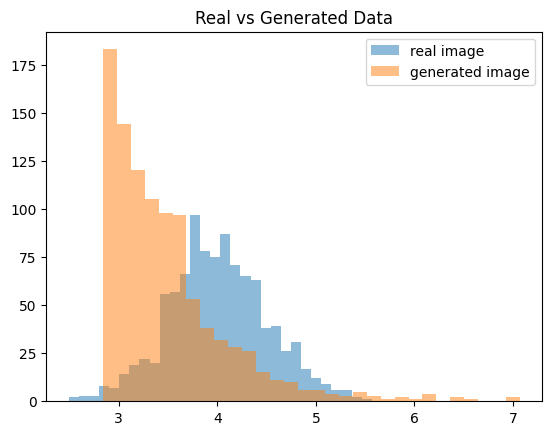

In [21]:
### generate Sample of Traning
noise = tf.random.normal([1000, 1])
generated_sample = generator_model(noise).numpy()
real_samples = get_real_data(1000)

## Plot real vs Generated Data
plt.hist(real_samples, bins=30, alpha=0.5, label='real image')
plt.hist(generated_sample, bins=30, alpha=0.5, label='generated image')
plt.legend()
plt.title('Real vs Generated Data')
plt.show()